---
title : "Dam Live"
---

In [1]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter

## Inladen van belastingen FEWS HHNK

<details>
<summary>Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    aquo_alias:
        H.meting: "WATHTE"
        WATHTE [m][NAP][OW]: "WATHTE"

    LoadsFews:
        host: "https://fews.hhnk.nl"
        port: 443
        region: "fewspiservice"
        version: "1.25"
        parameters: [ "H.meting", "WATHTE [m][NAP][OW]" ]

DataAdapter:
    default_options:
        csv:
            sep: ","
    locaties:
        type: csv
        path: "locations_fews.csv"
    waterstanden:
        type: csv
        path: "hidden_waterstanden_fews.csv"
    waterstanden_xml:
        type: xml_timeseries
        path: "waterstanden_fews.xml"
        parameter_mapping:
            WATHTE: H.meting
        location_mapping:
            MPN-N-24: BP

```

</details>

In [2]:
config = Config(
    config_path=Path().cwd()
    / "data_sets"
    / "run_damlive"
    / "test_loads_fews_grondwater.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

In [3]:
from toolbox_continu_inzicht.loads.loads_fews.loads_fews import LoadsFews


loads_fews = LoadsFews(data_adapter=data_adapter)

In [4]:
df_out = loads_fews.run(input="locaties", output="waterstanden_xml")

In [5]:
data_adapter.input("waterstanden_xml")
file = data_adapter.config.data_adapters["waterstanden_xml"]["abs_path"]
with open(file) as f:
    xml_content = f.read()
# laast bovenste stukje van de xml zien
print(xml_content[:1300])

<?xml version="1.0" encoding="UTF-8"?>
<TimeSeries xmlns="http://www.wldelft.nl/fews/PI" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.wldelft.nl/fews/PI https://fewsdocs.deltares.nl/schemas/version1.0/pi-schemas/pi_timeseries.xsd" version="1.2">
	<timeZone>1.0</timeZone>
    <series>
        <header>
            <type>instantaneous</type>
            <locationId>PB-288</locationId>
            <parameterId>H.meting</parameterId>
            <timeStep unit="second" multiplier="3600"/>
            <startDate date="2024-11-06" time="08:00:00"/>
            <endDate date="2024-11-07" time="08:00:00"/>
            <missVal>-999.0</missVal>
            <stationName>PB-288</stationName>
            <units>m</units>
        </header>
        <event date="2024-11-06" time="08:00:00" value="-2.145" flag="0"/>
        <event date="2024-11-06" time="09:00:00" value="-2.148" flag="0"/>
        <event date="2024-11-06" time="10:00:00" value="-2.145" flag="0"/>

Voor het geval dat FEWS HHNK niet beschikbaar is, kan met het volgende bestand wel gerekend worden.
In het voorbeeld van FEWS hierboven is het een xml bestand maar elke tabel met meetreeks data kan gebruikt worden.

Bijvoorbeeld de csv:

```yaml
...
waterstanden:
    type: csv
    path: "waterstanden_fews.csv"
...
```

In [6]:
data_adapter.input("waterstanden_xml")

,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,2024-11-06 07:00:00+00:00,PB-288,H.meting,7923844,m,-2.145,9960009
1,2024-11-06 08:00:00+00:00,PB-288,H.meting,7923844,m,-2.148,9960009
2,2024-11-06 09:00:00+00:00,PB-288,H.meting,7923844,m,-2.145,9960009
3,2024-11-06 10:00:00+00:00,PB-288,H.meting,7923844,m,-2.152,9960009
4,2024-11-06 11:00:00+00:00,PB-288,H.meting,7923844,m,-2.149,9960009
...,...,...,...,...,...,...,...
192,2024-11-07 06:00:00+00:00,BP,H.meting,7923844,m,-0.466,9700324
193,2024-11-07 06:15:00+00:00,BP,H.meting,7923844,m,-0.475,9700324
194,2024-11-07 06:30:00+00:00,BP,H.meting,7923844,m,-0.464,9700324
195,2024-11-07 06:45:00+00:00,BP,H.meting,7923844,m,-0.485,9700324


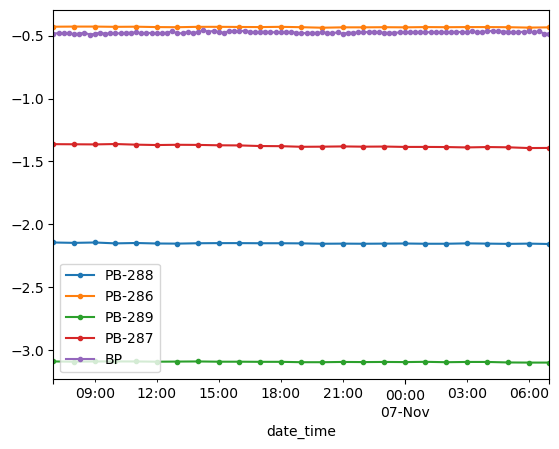

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
df_waterstanden = data_adapter.input("waterstanden_xml")
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

# loads to moments

Een deel van de data vanuit fews komt als kwartier data binnen, om dit naar uren te zetten wordt loads to moments gebruikt

In [8]:
from toolbox_continu_inzicht.loads import LoadsToMoments

Voor dit voorbeeld doen we nu even 2 tijdstappen

In [9]:
data_adapter.set_global_variable("moments", [i for i in range(0, 2, 1)])

In [10]:
loads_to_moments = LoadsToMoments(data_adapter=data_adapter)
loads_to_moments.run(input="waterstanden_xml", output="waterstanden_xml_hourly")

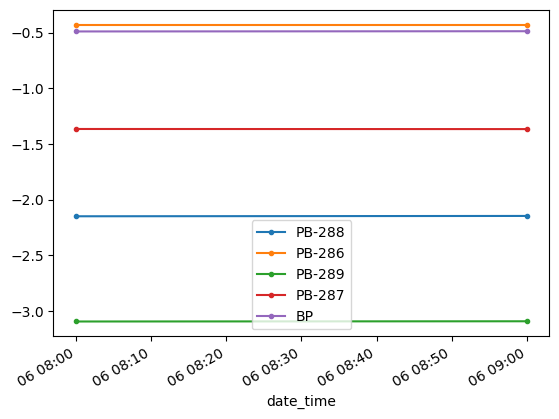

In [11]:
fig, ax = plt.subplots()
df_waterstanden = loads_to_moments.df_out
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

## Runnen van dam_live

Voor dam live is een licentie van Deltares nodig.

Dit voorbeeld is gemaakt met een versie van damlive versie 26.1.0.7015.


In [12]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter


<details>
<summary> Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    UpdateDamLive:
        DAMLIVE_FILE: 'WV2030_Purmer.damx'
        delete_output_folder: False

DataAdapter:
    default_options:
        csv:
            sep: ","
    waterstanden_xml_uur:
        type: xml_timeseries
        path: "waterstanden_fews_hourly.xml"
    parameters_bishop_csv:
        type: csv
        index: True
        path: "parameters_bishop.csv"
    parameters_uplift_csv:
        type: csv
        index: True
        path: "parameters_uplift.csv"
    output_file:
        type: csv
        path: test.csv

``` 
</details>


In [13]:
config = Config(
    config_path=Path().cwd() / "data_sets" / "run_damlive" / "run_damlive.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

De benoemde waterstand metingen tabel moet mee gegeven worden

In [14]:
data_adapter.input("waterstanden_xml_uur")

,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,2024-11-06 07:00:00+00:00,PB-288,H.meting,7923844,m,-2.148,9960009
1,2024-11-06 08:00:00+00:00,PB-288,H.meting,7923844,m,-2.145,9960009
2,2024-11-06 07:00:00+00:00,PB-286,H.meting,7923844,m,-0.428,1578348
3,2024-11-06 08:00:00+00:00,PB-286,H.meting,7923844,m,-0.428,1578348
4,2024-11-06 07:00:00+00:00,PB-289,H.meting,7923844,m,-3.093,1131647
5,2024-11-06 08:00:00+00:00,PB-289,H.meting,7923844,m,-3.091,1131647
6,2024-11-06 07:00:00+00:00,PB-287,H.meting,7923844,m,-1.364,6353575
7,2024-11-06 08:00:00+00:00,PB-287,H.meting,7923844,m,-1.365,6353575
8,2024-11-06 07:00:00+00:00,BP,H.meting,7923844,m,-0.488,9700324
9,2024-11-06 08:00:00+00:00,BP,H.meting,7923844,m,-0.486,9700324


En de parameters moeten ook nog worden mee geven, in dit geval rekenen we met bishop

Daarnaast moet in de `root_dir` een `{project_naam}.damx` bestand staan wat uitvoer is van een [`Dam stabiliteit`](https://publicwiki.deltares.nl/spaces/DAM/pages/166462239/Aanmaken+DAM+Live+project) berekening, en een map met de stix bestanden: `{project_naam}.geometries2D` waar in het `.damx` bestand naar wordt verwezen. 

In dit voorbeeld is de `project_naam`:  `WV2030_Purmer`. 

Het projectnaam moet meegeven worden in de opties, 

In [16]:
from toolbox_continu_inzicht.dam_live import UpdateDamLive

update_dam_live = UpdateDamLive(data_adapter=data_adapter)

In [17]:
# om meer informatie terug te krijgen van DAMLIVE, kan de logging level op INFO worden gezet.
update_dam_live.data_adapter.set_global_variable("logging", {"level": "INFO"})
update_dam_live.data_adapter.init_logging(re_initialize=True)

Dit duurt ca 2 min voor 2 tijdstappen: 

In [ ]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_bishop_csv"], output="output_file"
)

In [ ]:
update_dam_live.data_adapter.input("output_file").head(5)

## Herhaal met UpliftVan

Dit duurt ca 5min voor 2 tijdstappen: 

In [18]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_uplift_csv"], output="output_file"
)

2026-03-09 13:59:35 INFO - run: 2026-03-09 13:59:35,843 [1] INFO  DamLive DamLive 26.1.0.7015
2026-03-09 13:59:35 INFO - run: 2026-03-09 13:59:35,871 [1] INFO  DamLive Copyright ¸ Deltares 2026
2026-03-09 13:59:35 INFO - run: 2026-03-09 13:59:35,871 [1] INFO  DamLive Model runner started
2026-03-09 13:59:35 INFO - run: 
2026-03-09 14:12:21 INFO - run: 2026-03-09 14:12:21,950 [1] INFO  Deltares.DamLive.Application.DamEngineRunner There are 16 locations with sensor data
2026-03-09 14:12:22 INFO - run: 
2026-03-09 14:12:22 INFO - run: 2026-03-09 14:12:22,052 [1] INFO  DamLive Model runner ended


In [19]:
update_dam_live.data_adapter.input("output_file").head(5)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,6146190,m,1.047054,5294208
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,6146190,m,0.672593,5294208
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,6146190,m,0.763164,4207347
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,6146190,m,0.763183,4207347
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,6146190,m,0.773453,7231420
